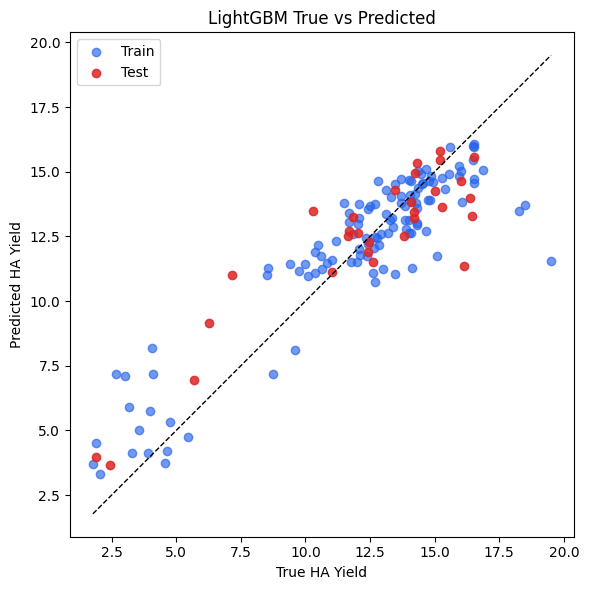

Fixed Parameters:
{'colsample_bytree': 0.7728434442477368, 'learning_rate': 0.0035099451126927843, 'max_bin': 164, 'max_depth': 15, 'min_child_samples': 12, 'min_split_gain': 0.0006723396861006931, 'n_estimators': 1161, 'num_leaves': 177, 'reg_alpha': 0.0010103063701743973, 'reg_lambda': 0.002652385528961019, 'subsample': 0.9757392798329956, 'subsample_freq': 2}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2286%

===== Cross-Validation Results =====
MSE : 3.1408
RMSE: 1.7722
MAE : 1.4067
MRE : 14.76%
R2  : 0.7880

===== Training Set Metrics =====
MSE: 2.9062
RMSE: 1.7047
MAE: 1.2195
MRE: 16.15%
R2: 0.8134

===== Test Set Metrics =====
MSE: 3.2388
RMSE: 1.7997
MAE: 1.4016
MRE: 16.65%
R2: 0.7857

Results saved to: E:\YRH-HSI\python data\MUST\LightGBM.xlsx
Visualizations saved to: E:\YRH-HSI\python data\MUST\lightgbm_fixed_params_visualization


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lightgbm import LGBMRegressor

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM.xlsx")
output_dir = spectra_path.parent / "lightgbm_fixed_params_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col_spectra = spectra_df.columns[0]
id_col_label = label_df.columns[0]
target_col = label_df.columns[1]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col_spectra] = spectra_df[id_col_spectra].map(normalize_id)
label_df[id_col_label] = label_df[id_col_label].map(normalize_id)

label_df = label_df[[id_col_label, target_col]].copy()
label_df = label_df.rename(columns={id_col_label: id_col_spectra})

label_check = label_df.groupby(id_col_spectra)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col_spectra], keep="first")
df = spectra_df.merge(label_unique, on=id_col_spectra, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col_spectra].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]

X = df[feature_cols].astype(float)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted from the current data, cannot set to 5.")

X_pls_input = X_standard.values
y_pls_input = y.values.reshape(-1, 1)

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_pls_input, y_pls_input)

X_scores = pls.x_scores_
X_loadings = pls.x_loadings_

X_reconstructed = X_scores @ X_loadings.T
ss_total = np.sum(X_pls_input ** 2)
ss_residual = np.sum((X_pls_input - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]

df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col_spectra, df[id_col_spectra].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col_spectra].astype(str)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

fixed_params = {
    "colsample_bytree": 0.7728434442477368,
    "learning_rate": 0.0035099451126927843,
    "max_bin": 164,
    "max_depth": 15,
    "min_child_samples": 12,
    "min_split_gain": 0.0006723396861006931,
    "n_estimators": 1161,
    "num_leaves": 177,
    "reg_alpha": 0.0010103063701743973,
    "reg_lambda": 0.002652385528961019,
    "subsample": 0.9757392798329956,
    "subsample_freq": 2
}

cv = GroupKFold(n_splits=5)
train_idx_cv, val_idx_cv = next(cv.split(X_train, y_train, groups=groups_train))

X_tr = X_train.iloc[train_idx_cv]
y_tr = y_train.iloc[train_idx_cv]
X_val = X_train.iloc[val_idx_cv]
y_val = y_train.iloc[val_idx_cv]

model_cv = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model_cv.fit(X_tr, y_tr)
y_pred = model_cv.predict(X_val)

cv_mse = mean_squared_error(y_val, y_pred)
cv_rmse = np.sqrt(cv_mse)
cv_mae = mean_absolute_error(y_val, y_pred)
cv_mre = np.mean(np.abs(y_val - y_pred) / y_val) * 100
cv_r2 = r2_score(y_val, y_pred)

model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[train_idx][id_col_spectra].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})

test_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[test_idx][id_col_spectra].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})

all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    x = str(x).strip()
    try:
        return float(x)
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col_spectra].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col_spectra).cumcount() + 1

all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"],
    ascending=[True, True]
).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE",
        "CV RMSE",
        "CV MAE",
        "CV MRE(%)",
        "CV R2",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})

fixed_params_df = pd.DataFrame(
    list(fixed_params.items()),
    columns=["Parameter", "Fixed Value"]
)

feature_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("LightGBM True vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_5", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

print("Fixed Parameters:")
print(fixed_params)

print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")

print("\n===== Cross-Validation Results =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")

print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")

print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print(f"\nResults saved to: {output_path}")
print(f"Visualizations saved to: {output_dir}")

In [69]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from lightgbm import LGBMRegressor

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM_SingleRunResult.xlsx")
output_dir = spectra_path.parent / "lightgbm_fixed_params_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path)
label_df = pd.read_excel(label_path)

id_col_spectra = spectra_df.columns[0]
id_col_label = label_df.columns[0]
target_col = label_df.columns[1]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col_spectra] = spectra_df[id_col_spectra].map(normalize_id)
label_df[id_col_label] = label_df[id_col_spectra].map(normalize_id)

label_df = label_df[[id_col_label, target_col]].copy()
label_df = label_df.rename(columns={id_col_label: id_col_spectra})

label_check = label_df.groupby(id_col_spectra)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col_spectra], keep="first")
df = spectra_df.merge(label_unique, on=id_col_spectra, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col_spectra].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]

X = df[feature_cols].astype(float)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted from the current data, cannot set to 5.")

X_pls_input = X_standard.values
y_pls_input = y.values.reshape(-1, 1)

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_pls_input, y_pls_input)

X_scores = pls.x_scores_
X_loadings = pls.x_loadings_

X_reconstructed = X_scores @ X_loadings.T
ss_total = np.sum(X_pls_input ** 2)
ss_residual = np.sum((X_pls_input - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]

df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col_spectra, df[id_col_spectra].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col_spectra].astype(str)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

fixed_params = {
    "colsample_bytree": 0.7728434442477368,
    "learning_rate": 0.0035099451126927843,
    "max_bin": 164,
    "max_depth": 15,
    "min_child_samples": 12,
    "min_split_gain": 0.0006723396861006931,
    "n_estimators": 1161,
    "num_leaves": 177,
    "reg_alpha": 0.0010103063701743973,
    "reg_lambda": 0.002652385528961019,
    "subsample": 0.9757392798329956,
    "subsample_freq": 2
}

cv = GroupKFold(n_splits=5)
train_idx_cv, val_idx_cv = next(cv.split(X_train, y_train, groups=groups_train))

X_tr = X_train.iloc[train_idx_cv]
y_tr = y_train.iloc[train_idx_cv]
X_val = X_train.iloc[val_idx_cv]
y_val = y_train.iloc[val_idx_cv]

model_cv = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model_cv.fit(X_tr, y_tr)
y_pred = model_cv.predict(X_val)

cv_mse = mean_squared_error(y_val, y_pred)
cv_rmse = np.sqrt(cv_mse)
cv_mae = mean_absolute_error(y_val, y_pred)
cv_mre = np.mean(np.abs(y_val - y_pred) / y_val) * 100
cv_r2 = r2_score(y_val, y_pred)

model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[train_idx][id_col_spectra].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})

test_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[test_idx][id_col_spectra].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})

all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    x = str(x).strip()
    try:
        return float(x)
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col_spectra].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col_spectra).cumcount() + 1

all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"],
    ascending=[True, True]
).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE",
        "CV RMSE",
        "CV MAE",
        "CV MRE(%)",
        "CV R2",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})

fixed_params_df = pd.DataFrame(
    list(fixed_params.items()),
    columns=["Parameter", "Fixed Value"]
)

feature_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

perm_result = permutation_importance(
    estimator=model,
    X=X_test,
    y=y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_Std": perm_result.importances_std,
    "Permutation_Importance_Std_Square": perm_result.importances_std ** 2
}).sort_values("Permutation_Importance_Mean", ascending=False)


with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_5", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="lgbm_gain_importance", index=False)
    perm_importance_df.to_excel(writer, sheet_name="permutation_importance", index=False)

print("Fixed Parameters:")
print(fixed_params)

print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")

print("\n===== Cross-Validation Results =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")

print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")

print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print("\n===== Permutation Importance Ranking (Test Set) =====")
print(perm_importance_df.to_string(index=False))

print(f"\nResults saved to: {output_path}")
print(f"Visualizations saved to: {output_dir}")

Fixed Parameters:
{'colsample_bytree': 0.7728434442477368, 'learning_rate': 0.0035099451126927843, 'max_bin': 164, 'max_depth': 15, 'min_child_samples': 12, 'min_split_gain': 0.0006723396861006931, 'n_estimators': 1161, 'num_leaves': 177, 'reg_alpha': 0.0010103063701743973, 'reg_lambda': 0.002652385528961019, 'subsample': 0.9757392798329956, 'subsample_freq': 2}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2286%

===== Cross-Validation Results =====
MSE : 3.1408
RMSE: 1.7722
MAE : 1.4067
MRE : 14.76%
R2  : 0.7880

===== Training Set Metrics =====
MSE: 2.9062
RMSE: 1.7047
MAE: 1.2195
MRE: 16.15%
R2: 0.8134

===== Test Set Metrics =====
MSE: 3.2388
RMSE: 1.7997
MAE: 1.4016
MRE: 16.65%
R2: 0.7857

===== Permutation Importance Ranking (Test Set) =====
        Feature  Permutation_Importance_Mean  Permutation_Importance_Std  Permutation_Importance_Std_Square
PLS_Component_1                     0.839567                    0.265104                           0.070280
PLS_Component_4   

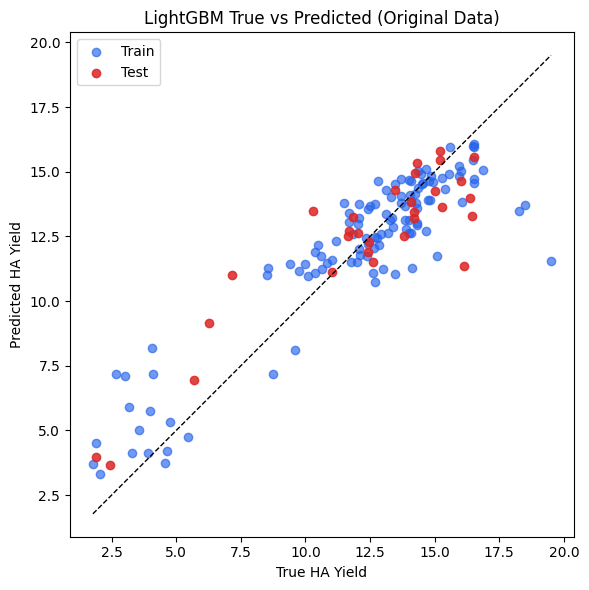

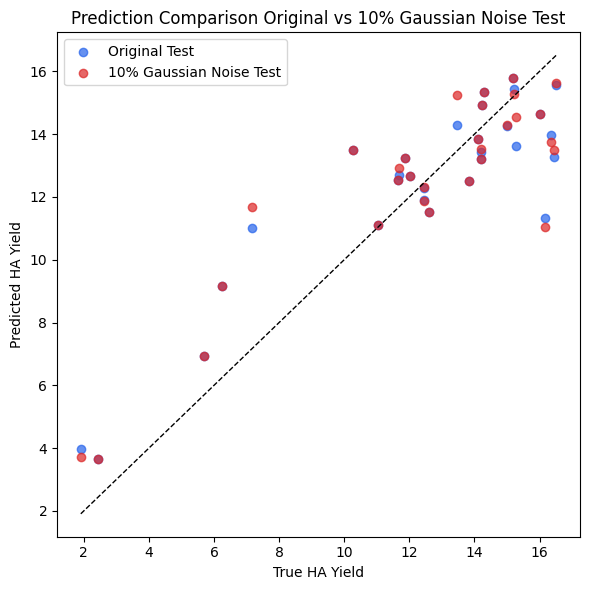

Fixed Parameters:
{'colsample_bytree': 0.7728434442477368, 'learning_rate': 0.0035099451126927843, 'max_bin': 164, 'max_depth': 15, 'min_child_samples': 12, 'min_split_gain': 0.0006723396861006931, 'n_estimators': 1161, 'num_leaves': 177, 'reg_alpha': 0.0010103063701743973, 'reg_lambda': 0.002652385528961019, 'subsample': 0.9757392798329956, 'subsample_freq': 2}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2286%

===== Cross-Validation Results =====
MSE : 3.1408
RMSE: 1.7722
MAE : 1.4067
MRE : 14.76%
R2  : 0.7880

===== Training Set Metrics =====
MSE: 2.9062
RMSE: 1.7047
MAE: 1.2195
MRE: 16.15%
R2: 0.8134

===== Original Test Set Metrics =====
MSE: 3.2388
RMSE: 1.7997
MAE: 1.4016
MRE: 16.65%
R2: 0.7857

===== Test Set With 10% Gaussian Noise =====
MSE: 3.5093
RMSE: 1.8733
MAE: 1.4255
MRE: 16.65%
R2: 0.7678
R2 reduction after noise: 0.0179

Results saved to: E:\YRH-HSI\python data\MUST\LightGBM-Gaussian Noise.xlsx
Visualizations saved to: E:\YRH-HSI\python data\MUST\lightgbm_fix

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lightgbm import LGBMRegressor

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM-Gaussian Noise.xlsx")
output_dir = spectra_path.parent / "lightgbm_fixed_params_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path)
label_df = pd.read_excel(label_path)

id_col_spectra = spectra_df.columns[0]
id_col_label = label_df.columns[0]
target_col = label_df.columns[1]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col_spectra] = spectra_df[id_col_spectra].map(normalize_id)
label_df[id_col_label] = label_df[id_col_label].map(normalize_id)

label_df = label_df[[id_col_label, target_col]].copy()
label_df = label_df.rename(columns={id_col_label: id_col_spectra})

label_check = label_df.groupby(id_col_spectra)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col_spectra], keep="first")
df = spectra_df.merge(label_unique, on=id_col_spectra, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col_spectra].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]

X = df[feature_cols].astype(float)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted from the current data, cannot set to 5.")

X_pls_input = X_standard.values
y_pls_input = y.values.reshape(-1, 1)

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_pls_input, y_pls_input)

X_scores = pls.x_scores_
X_loadings = pls.x_loadings_

X_reconstructed = X_scores @ X_loadings.T
ss_total = np.sum(X_pls_input ** 2)
ss_residual = np.sum((X_pls_input - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]

df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col_spectra, df[id_col_spectra].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col_spectra].astype(str)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

fixed_params = {
    "colsample_bytree": 0.7728434442477368,
    "learning_rate": 0.0035099451126927843,
    "max_bin": 164,
    "max_depth": 15,
    "min_child_samples": 12,
    "min_split_gain": 0.0006723396861006931,
    "n_estimators": 1161,
    "num_leaves": 177,
    "reg_alpha": 0.0010103063701743973,
    "reg_lambda": 0.002652385528961019,
    "subsample": 0.9757392798329956,
    "subsample_freq": 2
}

cv = GroupKFold(n_splits=5)
train_idx_cv, val_idx_cv = next(cv.split(X_train, y_train, groups=groups_train))

X_tr = X_train.iloc[train_idx_cv]
y_tr = y_train.iloc[train_idx_cv]
X_val = X_train.iloc[val_idx_cv]
y_val = y_train.iloc[val_idx_cv]

model_cv = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model_cv.fit(X_tr, y_tr)
y_pred = model_cv.predict(X_val)

cv_mse = mean_squared_error(y_val, y_pred)
cv_rmse = np.sqrt(cv_mse)
cv_mae = mean_absolute_error(y_val, y_pred)
cv_mre = np.mean(np.abs(y_val - y_pred) / y_val) * 100
cv_r2 = r2_score(y_val, y_pred)

model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[train_idx][id_col_spectra].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})

test_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[test_idx][id_col_spectra].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})

all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    x = str(x).strip()
    try:
        return float(x)
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col_spectra].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col_spectra).cumcount() + 1

all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"],
    ascending=[True, True]
).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE",
        "CV RMSE",
        "CV MAE",
        "CV MRE(%)",
        "CV R2",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})

fixed_params_df = pd.DataFrame(
    list(fixed_params.items()),
    columns=["Parameter", "Fixed Value"]
)

feature_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("LightGBM True vs Predicted (Original Data)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_original.png", dpi=300)
plt.show()

noise_level = 0.10
np.random.seed(42)
X_standard_test = X_standard.iloc[test_idx].copy().values
n_sample, n_wave = X_standard_test.shape
noise = np.random.normal(0, noise_level, X_standard_test.shape)
X_standard_test_noisy = X_standard_test + noise

X_noise_pls = pls.transform(X_standard_test_noisy)
X_noise_df = pd.DataFrame(X_noise_pls, columns=pls_cols)
y_test_noise_pred = model.predict(X_noise_df)

noise_test_mse = mean_squared_error(y_test, y_test_noise_pred)
noise_test_rmse = np.sqrt(noise_test_mse)
noise_test_mae = mean_absolute_error(y_test, y_test_noise_pred)
noise_test_mre = np.mean(np.abs(y_test - y_test_noise_pred) / y_test) * 100
noise_test_r2 = r2_score(y_test, y_test_noise_pred)

noise_metrics_df = pd.DataFrame({
    "Metric": [
        "Noise Type",
        "Noise Level",
        "Original Test MSE",
        "Noisy Test MSE",
        "Original Test RMSE",
        "Noisy Test RMSE",
        "Original Test MAE",
        "Noisy Test MAE",
        "Original Test MRE(%)",
        "Noisy Test MRE(%)",
        "Original Test R2",
        "Noisy Test R2",
        "R2 Drop After Noise"
    ],
    "Value": [
        "10% Gaussian Noise",
        f"{noise_level*100}%",
        test_mse,
        noise_test_mse,
        test_rmse,
        noise_test_rmse,
        test_mae,
        noise_test_mae,
        test_mre,
        noise_test_mre,
        test_r2,
        noise_test_r2,
        test_r2 - noise_test_r2
    ]
})

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, label="Original Test", color="#2563EB")
plt.scatter(y_test, y_test_noise_pred, alpha=0.7, label="10% Gaussian Noise Test", color="#DC2626")
min_all = min(y_test.min(), y_test_pred.min(), y_test_noise_pred.min())
max_all = max(y_test.max(), y_test_pred.max(), y_test_noise_pred.max())
plt.plot([min_all, max_all], [min_all, max_all], "k--", lw=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("Prediction Comparison Original vs 10% Gaussian Noise Test")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "noise_comparison_scatter.png", dpi=300)
plt.show()

noisy_test_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[test_idx][id_col_spectra].values,
    "True HA Yield": y_test.values,
    "Noisy Predicted HA Yield": y_test_noise_pred
})

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_5", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)
    noise_metrics_df.to_excel(writer, sheet_name="noise_robustness_metrics", index=False)
    noisy_test_df.to_excel(writer, sheet_name="noisy_test_predictions", index=False)

print("Fixed Parameters:")
print(fixed_params)

print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")

print("\n===== Cross-Validation Results =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")

print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")

print(f"\n===== Original Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print(f"\n===== Test Set With 10% Gaussian Noise =====")
print(f"MSE: {noise_test_mse:.4f}")
print(f"RMSE: {noise_test_rmse:.4f}")
print(f"MAE: {noise_test_mae:.4f}")
print(f"MRE: {noise_test_mre:.2f}%")
print(f"R2: {noise_test_r2:.4f}")
print(f"R2 reduction after noise: {(test_r2 - noise_test_r2):.4f}")

print(f"\nResults saved to: {output_path}")
print(f"Visualizations saved to: {output_dir}")

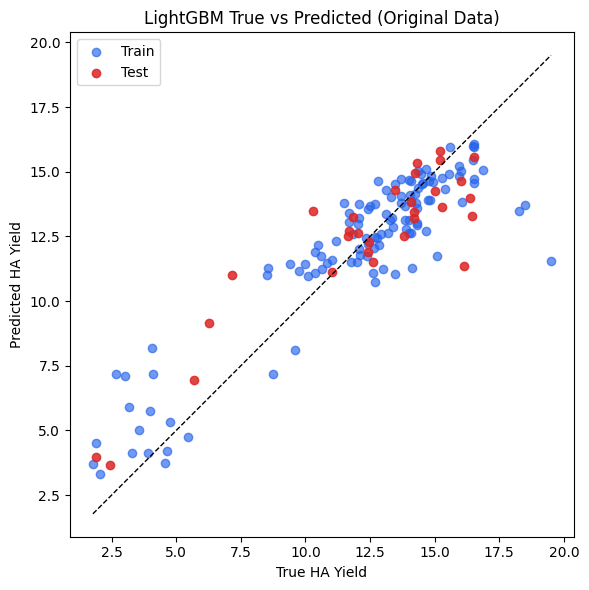

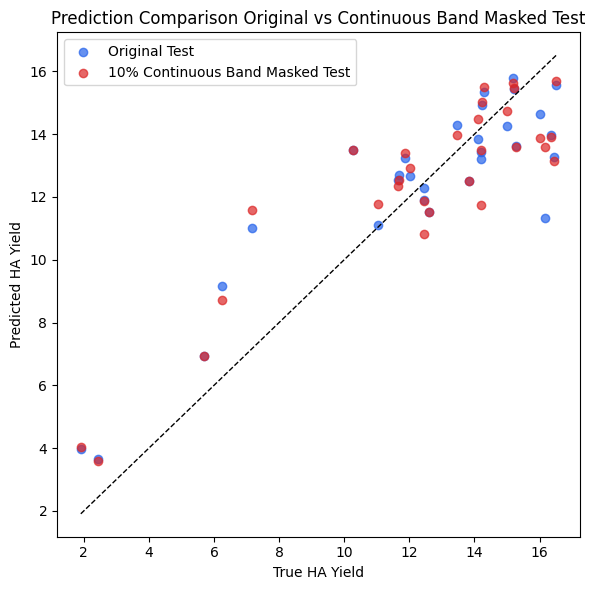

Fixed Parameters:
{'colsample_bytree': 0.7728434442477368, 'learning_rate': 0.0035099451126927843, 'max_bin': 164, 'max_depth': 15, 'min_child_samples': 12, 'min_split_gain': 0.0006723396861006931, 'n_estimators': 1161, 'num_leaves': 177, 'reg_alpha': 0.0010103063701743973, 'reg_lambda': 0.002652385528961019, 'subsample': 0.9757392798329956, 'subsample_freq': 2}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2286%
Total spectral bands: 512
Continuous masked band length per sample: 51

===== Cross-Validation Results =====
MSE : 3.1408
RMSE: 1.7722
MAE : 1.4067
MRE : 14.76%
R2  : 0.7880

===== Training Set Metrics =====
MSE: 2.9062
RMSE: 1.7047
MAE: 1.2195
MRE: 16.15%
R2: 0.8134

===== Original Test Set Metrics =====
MSE: 3.2388
RMSE: 1.7997
MAE: 1.4016
MRE: 16.65%
R2: 0.7857

===== Test Set With 10% Continuous Spectral Band Masking =====
MSE: 3.1804
RMSE: 1.7834
MAE: 1.4673
MRE: 17.34%
R2: 0.7896
R2 reduction after masking: -0.0039

Masking robustness analysis results saved to: E:

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lightgbm import LGBMRegressor

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM_MaskingAnalysis.xlsx")
output_dir = spectra_path.parent / "lightgbm_fixed_params_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path)
label_df = pd.read_excel(label_path)

id_col_spectra = spectra_df.columns[0]
id_col_label = label_df.columns[0]
target_col = label_df.columns[1]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col_spectra] = spectra_df[id_col_spectra].map(normalize_id)
label_df[id_col_label] = label_df[id_col_label].map(normalize_id)

label_df = label_df[[id_col_label, target_col]].copy()
label_df = label_df.rename(columns={id_col_label: id_col_spectra})

label_check = label_df.groupby(id_col_spectra)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col_spectra], keep="first")
df = spectra_df.merge(label_unique, on=id_col_spectra, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col_spectra].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]

X = df[feature_cols].astype(float)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted from the current data, cannot set to 5.")

X_pls_input = X_standard.values
y_pls_input = y.values.reshape(-1, 1)

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_pls_input, y_pls_input)

X_scores = pls.x_scores_
X_loadings = pls.x_loadings_

X_reconstructed = X_scores @ X_loadings.T
ss_total = np.sum(X_pls_input ** 2)
ss_residual = np.sum((X_pls_input - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]

df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col_spectra, df[id_col_spectra].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col_spectra].astype(str)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

fixed_params = {
    "colsample_bytree": 0.7728434442477368,
    "learning_rate": 0.0035099451126927843,
    "max_bin": 164,
    "max_depth": 15,
    "min_child_samples": 12,
    "min_split_gain": 0.0006723396861006931,
    "n_estimators": 1161,
    "num_leaves": 177,
    "reg_alpha": 0.0010103063701743973,
    "reg_lambda": 0.002652385528961019,
    "subsample": 0.9757392798329956,
    "subsample_freq": 2
}

cv = GroupKFold(n_splits=5)
train_idx_cv, val_idx_cv = next(cv.split(X_train, y_train, groups=groups_train))

X_tr = X_train.iloc[train_idx_cv]
y_tr = y_train.iloc[train_idx_cv]
X_val = X_train.iloc[val_idx_cv]
y_val = y_train.iloc[val_idx_cv]

model_cv = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model_cv.fit(X_tr, y_tr)
y_pred = model_cv.predict(X_val)

cv_mse = mean_squared_error(y_val, y_pred)
cv_rmse = np.sqrt(cv_mse)
cv_mae = mean_absolute_error(y_val, y_pred)
cv_mre = np.mean(np.abs(y_val - y_pred) / y_val) * 100
cv_r2 = r2_score(y_val, y_pred)

model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **fixed_params
)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[train_idx][id_col_spectra].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})

test_result_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[test_idx][id_col_spectra].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})

all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    x = str(x).strip()
    try:
        return float(x)
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col_spectra].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col_spectra).cumcount() + 1

all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"],
    ascending=[True, True]
).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE",
        "CV RMSE",
        "CV MAE",
        "CV MRE(%)",
        "CV R2",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})

fixed_params_df = pd.DataFrame(
    list(fixed_params.items()),
    columns=["Parameter", "Fixed Value"]
)

feature_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("LightGBM True vs Predicted (Original Data)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_original.png", dpi=300)
plt.show()

mask_ratio = 0.10
np.random.seed(42)
X_standard_test = X_standard.iloc[test_idx].copy().values
n_sample, n_wave = X_standard_test.shape
window_len = int(n_wave * mask_ratio)

for i in range(n_sample):
    start = np.random.randint(0, n_wave - window_len + 1)
    X_standard_test[i, start:start + window_len] = 0.0

X_mask_pls = pls.transform(X_standard_test)
X_mask_df = pd.DataFrame(X_mask_pls, columns=pls_cols)
y_test_mask_pred = model.predict(X_mask_df)

mask_test_mse = mean_squared_error(y_test, y_test_mask_pred)
mask_test_rmse = np.sqrt(mask_test_mse)
mask_test_mae = mean_absolute_error(y_test, y_test_mask_pred)
mask_test_mre = np.mean(np.abs(y_test - y_test_mask_pred) / y_test) * 100
mask_test_r2 = r2_score(y_test, y_test_mask_pred)

mask_metrics_df = pd.DataFrame({
    "Metric": [
        "Mask Type",
        "Mask Ratio",
        "Continuous Mask Window Length",
        "Original Test MSE",
        "Masked Test MSE",
        "Original Test RMSE",
        "Masked Test RMSE",
        "Original Test MAE",
        "Masked Test MAE",
        "Original Test MRE(%)",
        "Masked Test MRE(%)",
        "Original Test R2",
        "Masked Test R2",
        "R2 Drop After Masking"
    ],
    "Value": [
        "10% Continuous Spectral Band Mask",
        f"{mask_ratio*100}%",
        window_len,
        test_mse,
        mask_test_mse,
        test_rmse,
        mask_test_rmse,
        test_mae,
        mask_test_mae,
        test_mre,
        mask_test_mre,
        test_r2,
        mask_test_r2,
        test_r2 - mask_test_r2
    ]
})

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, label="Original Test", color="#2563EB")
plt.scatter(y_test, y_test_mask_pred, alpha=0.7, label="10% Continuous Band Masked Test", color="#DC2626")
min_all = min(y_test.min(), y_test_pred.min(), y_test_mask_pred.min())
max_all = max(y_test.max(), y_test_pred.max(), y_test_mask_pred.max())
plt.plot([min_all, max_all], [min_all, max_all], "k--", lw=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("Prediction Comparison Original vs Continuous Band Masked Test")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "mask_comparison_scatter.png", dpi=300)
plt.show()

masked_test_df = pd.DataFrame({
    id_col_spectra: df_pls.iloc[test_idx][id_col_spectra].values,
    "True HA Yield": y_test.values,
    "Masked Predicted HA Yield": y_test_mask_pred
})

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_5", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="original_metrics", index=False)
    mask_metrics_df.to_excel(writer, sheet_name="mask_robustness_metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)
    masked_test_df.to_excel(writer, sheet_name="masked_test_predictions", index=False)

print("Fixed Parameters:")
print(fixed_params)

print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print(f"Total spectral bands: {n_wave}")
print(f"Continuous masked band length per sample: {window_len}")

print("\n===== Cross-Validation Results =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")

print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")

print(f"\n===== Original Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print(f"\n===== Test Set With 10% Continuous Spectral Band Masking =====")
print(f"MSE: {mask_test_mse:.4f}")
print(f"RMSE: {mask_test_rmse:.4f}")
print(f"MAE: {mask_test_mae:.4f}")
print(f"MRE: {mask_test_mre:.2f}%")
print(f"R2: {mask_test_r2:.4f}")
print(f"R2 reduction after masking: {(test_r2 - mask_test_r2):.4f}")

print(f"\nMasking robustness analysis results saved to: {output_path}")
print(f"Visualizations saved to: {output_dir}")


==================== Average Performance Across All Seeds ====================
Average Test R2: 0.7583 ± 0.0464
Average Train R2: 0.8191 ± 0.0281

All seed stability results saved to: E:\YRH-HSI\python data\MUST\LightGBM_SeedStabilityResult.xlsx
R² fluctuation figure saved to: E:\YRH-HSI\python data\MUST\lightgbm_seed_test_visualization


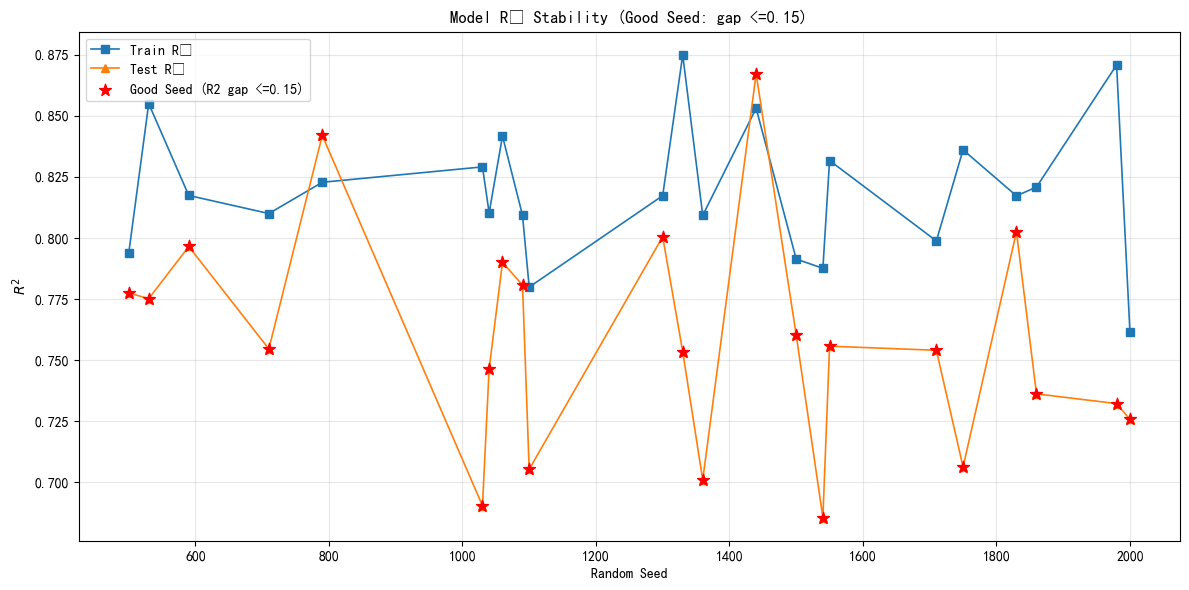

In [65]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lightgbm import LGBMRegressor

fixed_params = {
    "colsample_bytree": 0.7728434442477368,
    "learning_rate": 0.0035099451126927843,
    "max_bin": 164,
    "max_depth": 15,
    "min_child_samples": 12,
    "min_split_gain": 0.0006723396861006931,
    "n_estimators": 1161,
    "num_leaves": 177,
    "reg_alpha": 0.0010103063701743973,
    "reg_lambda": 0.002652385528961019,
    "subsample": 0.9757392798329956,
    "subsample_freq": 2
}
n_components = 4
seed_list = [500, 530, 590, 710, 790, 1030, 1040, 1060, 1090, 1100, 1300, 1330, 1360, 1440, 1500, 1540, 1550, 1710, 1750, 1830, 1860, 1980, 2000]
r2_diff_threshold = 0.15

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("LightGBM_SeedStabilityResult.xlsx")
output_dir = spectra_path.parent / "lightgbm_seed_test_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path)
label_df = pd.read_excel(label_path)

id_col_spectra = spectra_df.columns[0]
id_col_label = label_df.columns[0]
target_col = label_df.columns[1]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col_spectra] = spectra_df[id_col_spectra].map(normalize_id)
label_df[id_col_label] = label_df[id_col_label].map(normalize_id)

label_df = label_df[[id_col_label, target_col]].copy()
label_df = label_df.rename(columns={id_col_label: id_col_spectra})

label_check = label_df.groupby(id_col_spectra)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col_spectra], keep="first")
df = spectra_df.merge(label_unique, on=id_col_spectra, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col_spectra].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]
X = df[feature_cols].astype(float)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted from the current data, cannot set to {n_components}.")

X_pls_input = X_standard.values
y_pls_input = y.values.reshape(-1, 1)
pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_pls_input, y_pls_input)

X_scores = pls.x_scores_
X_loadings = pls.x_loadings_
X_reconstructed = X_scores @ X_loadings.T
ss_total = np.sum(X_pls_input ** 2)
ss_residual = np.sum((X_pls_input - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total
pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]

df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col_spectra, df[id_col_spectra].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col_spectra].astype(str)

seed_result_list = []
good_seed_list = []

for seed in seed_list:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
    X_train = X_model.iloc[train_idx]
    X_test = X_model.iloc[test_idx]
    y_train = y_model.iloc[train_idx]
    y_test = y_model.iloc[test_idx]

    model = LGBMRegressor(
        objective="regression",
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
        **fixed_params
    )
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
    train_r2 = r2_score(y_train, y_train_pred)

    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100
    test_r2 = r2_score(y_test, y_test_pred)

    r2_gap = abs(train_r2 - test_r2)
    is_good_seed = r2_gap <= r2_diff_threshold
    if is_good_seed:
        good_seed_list.append(seed)

    seed_row = {
        "RandomSeed": seed,
        "Train_Test_R2_Gap": r2_gap,
        "Is_Good_Seed(<=0.15)": is_good_seed,
        "Train_MSE": train_mse,
        "Train_MAE": train_mae,
        "Train_MRE(%)": train_mre,
        "Train_R2": train_r2,
        "Test_MSE": test_mse,
        "Test_MAE": test_mae,
        "Test_MRE(%)": test_mre,
        "Test_R2": test_r2
    }
    seed_result_list.append(seed_row)

seed_summary_df = pd.DataFrame(seed_result_list)

stat_cols = [c for c in seed_summary_df.columns if c not in ["RandomSeed","Is_Good_Seed(<=0.15)"]]
stat_summary = pd.DataFrame({
    "Metric": stat_cols,
    "Mean": [seed_summary_df[col].mean() for col in stat_cols],
    "Std": [seed_summary_df[col].std() for col in stat_cols],
    "CV(%)": [(seed_summary_df[col].std() / seed_summary_df[col].mean()) * 100 for col in stat_cols]
})

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(seed_summary_df["RandomSeed"], seed_summary_df["Train_R2"], marker="s", linewidth=1.2, label="Train R²")
ax1.plot(seed_summary_df["RandomSeed"], seed_summary_df["Test_R2"], marker="^", linewidth=1.2, label="Test R²")
good_df = seed_summary_df[seed_summary_df["Is_Good_Seed(<=0.15)"] == True]
ax1.scatter(good_df["RandomSeed"], good_df["Test_R2"], c="red", s=80, marker="*", zorder=5, label="Good Seed (R2 gap <=0.15)")

ax1.set_xlabel("Random Seed")
ax1.set_ylabel("$R^2$")
ax1.set_title(f"Model R² Stability (Good Seed: gap <={r2_diff_threshold})")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "seed_r2_stability.png", dpi=300)

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_5_components", index=False)
    seed_summary_df.to_excel(writer, sheet_name="all_seed_metrics", index=False)
    stat_summary.to_excel(writer, sheet_name="seed_stat_mean_std", index=False)
    pd.DataFrame(list(fixed_params.items()), columns=["Parameter", "Fixed Value"]).to_excel(writer, sheet_name="fixed_lgb_params", index=False)
    pd.DataFrame({"Good_Seed_List": good_seed_list}).to_excel(writer, sheet_name="good_seeds_filtered", index=False)


print("\n==================== Average Performance Across All Seeds ====================")
print(f"Average Test R2: {seed_summary_df['Test_R2'].mean():.4f} ± {seed_summary_df['Test_R2'].std():.4f}")
print(f"Average Train R2: {seed_summary_df['Train_R2'].mean():.4f} ± {seed_summary_df['Train_R2'].std():.4f}")

print(f"\nAll seed stability results saved to: {output_path}")
print(f"R² fluctuation figure saved to: {output_dir}")
plt.show()